# MIS/MVC QAOA parameter comparison

This example compares the shared-angle, orbit, and fully multi-angle parametrizations for penalty-free MIS/MVC QAOA on a small graph. The LX mixer remains the existing ordered projected-X construction; the orbit ansatz only ties its angles according to vertex orbits.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qaoa import QAOA, initializers, utils
from qaoa.initialstates import MIS_MVC_InitialState
from qaoa.mixers import VertexSubsetLXMixer, VertexSubsetOrbitLXMixer, Grover
from qaoa.problems import MIS_MVC_MultiAngle, MIS_MVC_Orbit, MIS_MVC_Problem

## Graph

Example from https://arxiv.org/abs/2607.27915

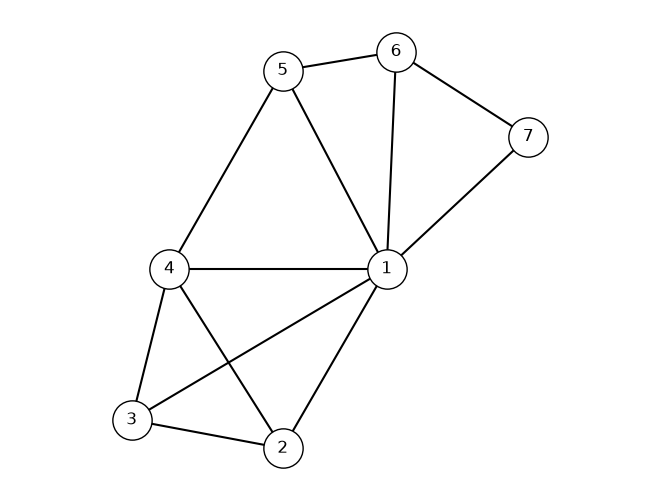

In [2]:
G = nx.Graph()

# Preserve node/qubit order: q0 -> node 1, ..., q6 -> node 7
G.add_nodes_from(range(1, 8))

G.add_edges_from([
    (1, 2),
    (1, 3),
    (1, 4),
    (1, 5),
    (1, 6),
    (1, 7),
    (2, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
])

pos = {
    1: (0.0, 0.0),
    2: (-0.55, -0.95),
    3: (-1.35, -0.80),
    4: (-1.15, 0.0),
    5: (-0.55, 1.05),
    6: (0.05, 1.15),
    7: (0.75, 0.70),
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    edgecolors="black",
    node_size=800,
    width=1.5,
)

plt.axis("equal")
plt.show()

## Choose MIS or MVC and build the three parametrizations

Set `problem_kind` to `"mis"` or `"mvc"`. The shared ansatz uses one `(γ, β)` pair per layer, the orbit ansatz uses one pair per vertex orbit, and the fully multi-angle ansatz uses one `(γ_i, β_i)` pair per vertex.

In [3]:
problem_kind = "mis"  # change to "mvc"
initial_angle = np.pi / 3
maxdepth = 10
shots = 2000

problem_shared = MIS_MVC_Problem(G, problem_kind=problem_kind)
problem_orbit = MIS_MVC_Orbit(G, problem_kind=problem_kind)
problem_multi = MIS_MVC_MultiAngle(G, problem_kind=problem_kind)

initial_state = MIS_MVC_InitialState(
    G,
    problem_kind=problem_kind,
    angle=initial_angle,
    phase_correct=True,
)

mixer_shared = VertexSubsetLXMixer(
    G,
    problem_kind=problem_kind,
    multi_angle=False,
)
mixer_orbit = VertexSubsetOrbitLXMixer(G, problem_kind=problem_kind)
mixer_multi = VertexSubsetLXMixer(
    G,
    problem_kind=problem_kind,
    multi_angle=True,
)

grover_mixer = Grover(initial_state)

degree_order = tuple(initial_state.node_order[target] for target in initial_state.vertex_order)
print("Problem:", problem_kind.upper())
print("Degree-ordered vertices:", degree_order)
print(f"Vertex orbits ({len(problem_orbit.orbits)} total):", problem_orbit.orbits)
print("Parameters per layer:")
print(
    f"  shared      : {problem_shared.get_num_parameters()} problem parameters + "
    f"{mixer_shared.get_num_parameters()} mixer parameters"
)
print(
    f"  orbit       : {problem_orbit.get_num_parameters()} problem parameters + "
    f"{mixer_orbit.get_num_parameters()} mixer parameters"
)
print(
    f"  multi-angle : {problem_multi.get_num_parameters()} problem parameters + "
    f"{mixer_multi.get_num_parameters()} mixer parameters"
)

Problem: MIS
Degree-ordered vertices: (1, 4, 2, 3, 5, 6, 7)
Vertex orbits (6 total): ((1,), (2, 3), (4,), (5,), (6,), (7,))
Parameters per layer:
  shared      : 1 problem parameters + 1 mixer parameters
  orbit       : 6 problem parameters + 6 mixer parameters
  multi-angle : 7 problem parameters + 7 mixer parameters


## Inspect the orbit-tied mixer and phase separator

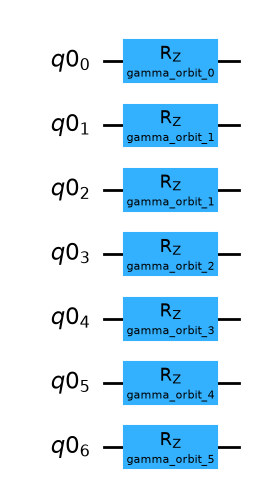

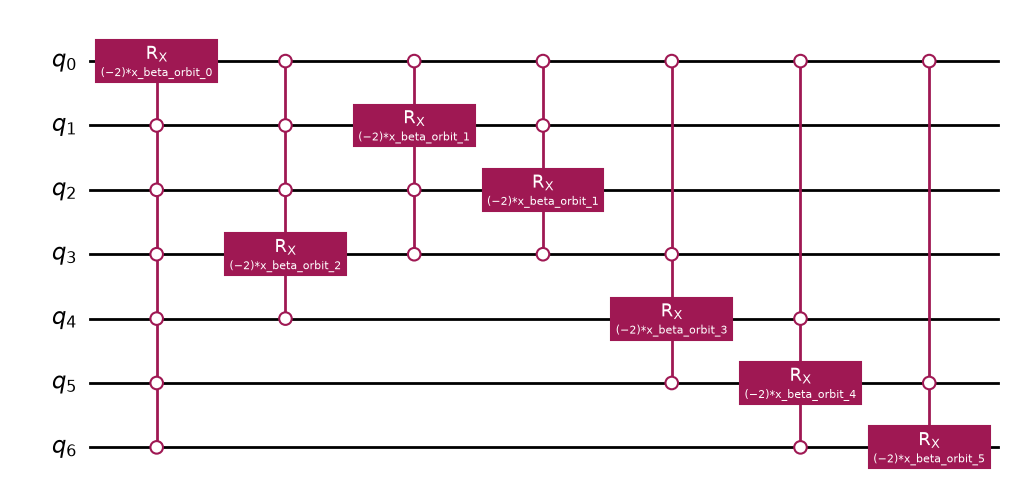

In [4]:
problem_orbit.create_circuit()
mixer_orbit.create_circuit()

display(problem_orbit.circuit.draw("mpl", fold=-1))
display(mixer_orbit.circuit.draw("mpl", fold=-1))

## Create QAOA instances

As in the MaxCut comparison example, the shared ansatz uses `Interp()` while orbit and fully multi-angle use `LayerGrid()` as a robust depth-extension initializer.

In [5]:
grid_initializer = initializers.LayerGrid(
    gamma_values=[0, 2 * np.pi, 20],
    beta_values=[0, np.pi, 10],
)

ansaetze = {
    "Grover": QAOA(
        problem=problem_shared,
        mixer=grover_mixer,
        initialstate=initial_state,
        shots=shots,
        initializer=initializers.Interp(),
    ),
    "Groverphaseorbit": QAOA(
        problem=problem_orbit,
        mixer=grover_mixer,
        initialstate=initial_state,
        shots=shots,
        initializer=initializers.Interp(),
    ),
    "shared": QAOA(
        problem=problem_shared,
        mixer=mixer_shared,
        initialstate=initial_state,
        shots=shots,
        initializer=initializers.Interp(),
    ),
    "orbit": QAOA(
        problem=problem_orbit,
        mixer=mixer_orbit,
        initialstate=initial_state,
        shots=shots,
        initializer=initializers.Interp(),
    ),
    "multi-angle": QAOA(
        problem=problem_multi,
        mixer=mixer_multi,
        initialstate=initial_state,
        shots=shots,
        initializer=initializers.Interp(),
    ),
}

## Run optimisation

In [6]:
for label, qaoa in ansaetze.items():
    print(f"Optimizing {label} ansatz...")
    qaoa.optimize(depth=maxdepth)

Optimizing Grover ansatz...
2026-09-02 09:43:27 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-09-02 09:43:27 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-09-02 09:43:27 [info     ] circuits: 400                  file=qaoa.qaoa func=sample_cost_landscape
2026-09-02 09:43:27 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-09-02 09:43:41 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-09-02 09:43:41 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape
2026-09-02 09:43:43 [info     ] energy(depth 1) = -2.0989999999999998 file=qaoa.qaoa func=optimize
2026-09-02 09:43:48 [info     ] energy(depth 2) = -2.3135      file=qaoa.qaoa func=optimize
2026-09-02 09:43:53 [info     ] energy(depth 3) = -2.5155000000000003 file=qaoa.qaoa func=optimize
2026-09-02 09:44:03 [info     ] e

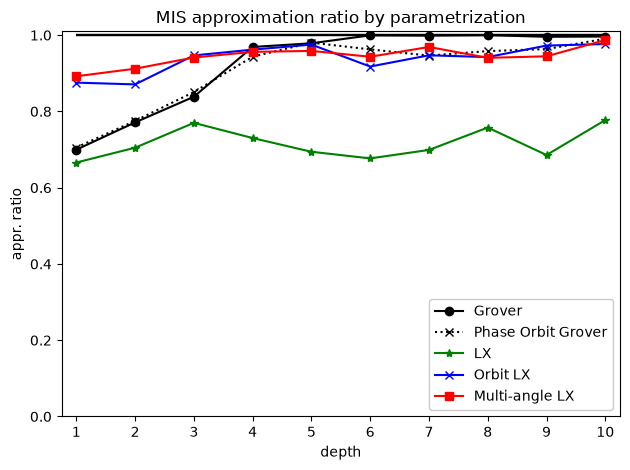

In [7]:
objmin, objmax = problem_shared.objective_bounds()

fig = plt.figure()
utils.plot_ApproximationRatio(ansaetze["Grover"], maxdepth, objmin, objmax, label="Grover", style="k-o", fig=fig)
utils.plot_ApproximationRatio(ansaetze["Groverphaseorbit"], maxdepth, objmin, objmax, label="Phase Orbit Grover", style="k:x", fig=fig)
utils.plot_ApproximationRatio(ansaetze["shared"], maxdepth, objmin, objmax, label="LX", style="g-*", fig=fig)
utils.plot_ApproximationRatio(ansaetze["orbit"], maxdepth, objmin, objmax, label="Orbit LX", style="b-x", fig=fig)
utils.plot_ApproximationRatio(ansaetze["multi-angle"], maxdepth, objmin, objmax, label="Multi-angle LX", style="r-s", fig=fig)
plt.title(f"{problem_kind.upper()} approximation ratio by parametrization")
plt.tight_layout()